In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from scipy.optimize import minimize

In [3]:
rodar_nm = False
resetar_banco = False

In [4]:
import os
import glob

# Sua variável de controle

# Caminho da pasta que será limpa
caminho_pasta = r'.\convergence_results'

if resetar_banco:
    # Cria uma lista com todos os itens (*) dentro da pasta
    arquivos = glob.glob(os.path.join(caminho_pasta, '*'))
    
    if not arquivos:
        print("A pasta já está vazia.")
    else:
        for arquivo in arquivos:
            try:
                # Garante que vai apagar apenas arquivos, ignorando subpastas caso existam
                if os.path.isfile(arquivo):
                    os.remove(arquivo)
                    print(f"Arquivo apagado: {arquivo}")
            except Exception as e:
                print(f"Erro ao tentar apagar {arquivo}: {e}")
                
        print(f"Limpeza da pasta {caminho_pasta} concluída com sucesso!")

In [5]:
data = [pd.read_csv(r'database\data_occ0_2.csv'),
        pd.read_csv(r'database\data_occ0_5.csv'),
        pd.read_csv(r'database\data_occ0_7.csv'),
        pd.read_csv(r'database\data_occ0_9.csv'),]

occ_name = ['0.2', '0.5', '0.7', '0.9']
parcela = len(data[0])
columns = data[0].columns
parcela

69994

In [6]:
def nm_minimize(df):
    def cost_function(A):
        signalPattern = np.array([
                A[0]*1.0    + A[1]*0.4524   + A[2]*0.0172   + 0             + 0             + 0             + 0,
                A[0]*0.5633 + A[1]*1        + A[2]*0.4524   + A[3]*0.0172   + 0             + 0             + 0,
                A[0]*0.1493 + A[1]*0.5633   + A[2]*1        + A[3]*0.4524   + A[4]*0.0172   + 0             + 0,
                A[0]*0.0424 + A[1]*0.1493   + A[2]*0.5633   + A[3]*1        + A[4]*0.4524   + A[5]*0.0172   + 0,
                0           + A[1]*0.0424   + A[2]*0.1493   + A[3]*0.5633   + A[4]*1        + A[5]*0.4524   + A[6]*0.0172,
                0           + 0             + A[2]*0.0424   + A[3]*0.1493   + A[4]*0.5633   + A[5]*1        + A[6]*0.4524,
                0           + 0             + 0             + A[3]*0.0424   + A[4]*0.1493   + A[5]*0.5633   + A[6]*1
                ])
        aux_sum = samples - signalPattern # "samples" are declared in each iteration of the for loop
        return (sum(aux_sum**2) / len(samples))**0.5


    def parada(xk):
                erro_atual = cost_function(xk)
                if erro_atual < 1:
                    raise StopIteration  
    sample4 = []
    c = 0
    m = 1
    for samples in df:
        res = minimize(cost_function, samples, method='Nelder-Mead', callback=parada, options={'maxiter': 700, 'xatol': 1e-100, 'fatol': 1e-100, 'disp': False, 'adaptive': False})
        sample4.append(res.x[3])
        c+=1
        if c == int(parcela*m/10):
            print(f"{m*10}% das operações foram concluídas.")
            m+=1

    return sample4

In [7]:
def nm_minimize_adaptativo(df):
    def cost_function(A):
        signalPattern = np.array([
                A[0]*1.0    + A[1]*0.4524   + A[2]*0.0172   + 0             + 0             + 0             + 0,
                A[0]*0.5633 + A[1]*1        + A[2]*0.4524   + A[3]*0.0172   + 0             + 0             + 0,
                A[0]*0.1493 + A[1]*0.5633   + A[2]*1        + A[3]*0.4524   + A[4]*0.0172   + 0             + 0,
                A[0]*0.0424 + A[1]*0.1493   + A[2]*0.5633   + A[3]*1        + A[4]*0.4524   + A[5]*0.0172   + 0,
                0           + A[1]*0.0424   + A[2]*0.1493   + A[3]*0.5633   + A[4]*1        + A[5]*0.4524   + A[6]*0.0172,
                0           + 0             + A[2]*0.0424   + A[3]*0.1493   + A[4]*0.5633   + A[5]*1        + A[6]*0.4524,
                0           + 0             + 0             + A[3]*0.0424   + A[4]*0.1493   + A[5]*0.5633   + A[6]*1
                ])
        aux_sum = samples - signalPattern # "samples" are declared in each iteration of the for loop
        return (sum(aux_sum**2) / len(samples))**0.5


    def parada(xk):
                erro_atual = cost_function(xk)
                if erro_atual < 1:
                    raise StopIteration  
    sample4 = []
    c = 0
    m = 1
    for samples in df:
        res = minimize(cost_function, samples, method='Nelder-Mead', callback=parada, options={'maxiter': 700, 'xatol': 1e-100, 'fatol': 1e-100, 'disp': False, 'adaptive': True})
        sample4.append(res.x[3])
        c+=1
        if c == int(parcela*m/10):
            print(f"{m*10}% das operações foram concluídas.")
            m+=1
    return sample4

In [8]:
def nm_algorithm(df, max_iter, tol_absValue):

    def cost_function(A):
        signalPattern = np.array([
                A[0]*1.0    + A[1]*0.4524   + A[2]*0.0172   + 0             + 0             + 0             + 0,
                A[0]*0.5633 + A[1]*1        + A[2]*0.4524   + A[3]*0.0172   + 0             + 0             + 0,
                A[0]*0.1493 + A[1]*0.5633   + A[2]*1        + A[3]*0.4524   + A[4]*0.0172   + 0             + 0,
                A[0]*0.0424 + A[1]*0.1493   + A[2]*0.5633   + A[3]*1        + A[4]*0.4524   + A[5]*0.0172   + 0,
                0           + A[1]*0.0424   + A[2]*0.1493   + A[3]*0.5633   + A[4]*1        + A[5]*0.4524   + A[6]*0.0172,
                0           + 0             + A[2]*0.0424   + A[3]*0.1493   + A[4]*0.5633   + A[5]*1        + A[6]*0.4524,
                0           + 0             + 0             + A[3]*0.0424   + A[4]*0.1493   + A[5]*0.5633   + A[6]*1
                ])
        aux_sum = samples - signalPattern # "samples" are declared in each iteration of the for loop
        return (sum(aux_sum**2) / len(samples))**0.5

    f = cost_function

    sample4 = []

    c = 0
    m = 1
    for samples in df:
        k = 0
        init_point = samples
        
        n = len(init_point) # number of dimensions of the function f
        # Adaptive Nelder-Mead Simplex
        alpha = 1 # reflection coefficient
        gamma = 1 + 2/n # expansion coefficient
        rho = 0.75 - 1/(2*n) # contraction coefficient
        sigma = 1 - 1/n # shrink coefficient

        # defines points for a initial simplex
        simplex = [init_point]    
        for i in range(0, n):
            aux_init_simplex = np.array(init_point, copy=True)
            for j in range(0, n):
                if i == j:
                    aux_init_simplex[i] += 0.05
            simplex.append(np.array(aux_init_simplex))

        # preparation for the loop
        
        while k < max_iter or max_iter == -1:
            simplex.sort(key = lambda x: f(x))
            best_value = f(simplex[0])
            worst_value = f(simplex[-1])

            # check the objetive function value and the interval
            if abs(best_value) < tol_absValue:#and np.mean(simplex[0] - simplex[-1]) < tol_interval
                break
            
            k += 1
            centroid = np.mean(simplex[:-1], axis = 0) # axis = 0 for efetuate the mean along the column
            
            # calculates reflection point
            reflected_point = centroid + alpha * (centroid - simplex[-1])
            reflected_value = f(reflected_point)

            # reflection
            if reflected_value >= best_value and reflected_value < f(simplex[-2]):
                simplex[-1] = reflected_point[:]
            
            # expansion
            elif reflected_value < best_value:
                expansion_point = centroid + gamma * (reflected_point - centroid)
                expansion_value = f(expansion_point)

                if expansion_value < reflected_value:
                    simplex[-1] = expansion_point[:]
                else:
                    simplex[-1] = reflected_point[:]
            
            # contraction
            else:
                if reflected_value < worst_value:
                    contracted_point = centroid + rho * (reflected_point - centroid)

                    if f(contracted_point) < reflected_value:
                        simplex[-1] = contracted_point[:]
                    # shrink
                    else:
                        for j in range(1, n + 1):
                            simplex[j] = simplex[0] + sigma * (simplex[j] - simplex[0])
                else:
                    contracted_point = centroid + rho * (simplex[-1] - centroid)
                    if f(contracted_point) < worst_value:
                        simplex[-1] = contracted_point[:]
                    # shrink
                    else:
                        for j in range(1, n + 1):
                            simplex[j] = simplex[0] + sigma * (simplex[j] - simplex[0])


        simplex.sort(key = lambda x: f(x))
        #print(simplex[0][3])
        sample4.append(simplex[0][3])
        c+=1
        #print(c)
        if c == int(parcela*m/10):
            print(f"{m*10}% das operações foram concluídas.")
            m+=1

    return sample4

In [9]:
def save_results(trueamp, estamp, occ, method):
    error_path = f'convergence_results/error_{occ}_{method}.csv'

    if not os.path.exists(error_path):
        df = pd.DataFrame({'Error': trueamp - estamp})
        df.to_csv(error_path, index=False)

    else:
        df = pd.read_csv(error_path)
        new_df = pd.DataFrame({'Error': trueamp - estamp})
        df = pd.concat([df, new_df], ignore_index=True)
        df.to_csv(error_path, index=False)

In [10]:
def load_results(method):
    res = [pd.read_csv(f'convergence_results/error_{occ}_{method}.csv') for occ in occ_name]
    return res


In [11]:
def run_neldermeads(data):
    if rodar_nm:

        for i in range(len(data)):
            samples_data = np.array(data[i][columns[0:7]][:parcela])
            amplitudes_data = np.array(data[i][columns[7]][:parcela])

            print(f"\nResultados para o Algorítmo Manual, ocupação: {occ_name[i]}")
            result = nm_algorithm(samples_data, max_iter=700, tol_absValue=1)
            save_results(amplitudes_data, result, occ_name[i], 'manual')

            print(f"\nResultados para o Algorítmo Minimize, ocupação: {occ_name[i]}")
            result = nm_minimize(samples_data)
            save_results(amplitudes_data, result, occ_name[i], 'minimize')

            print(f"\nResultados para o Algorítmo Minimize Adaptativo, ocupação: {occ_name[i]}")
            result = nm_minimize_adaptativo(samples_data)
            save_results(amplitudes_data, result, occ_name[i], 'adaptativo')
   

In [12]:
run_neldermeads(data)

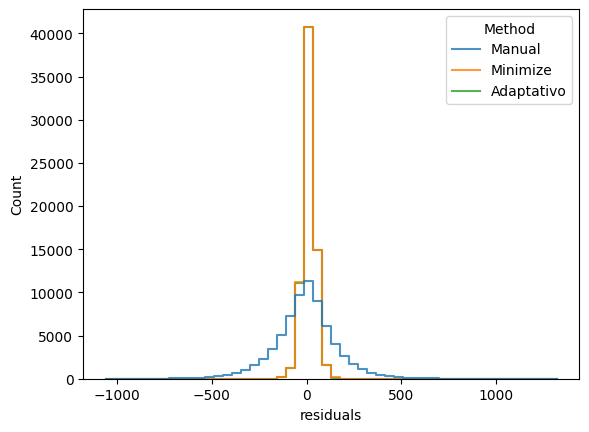

In [ ]:
res_manual = load_results('manual')
res_minimize = load_results('minimize')
res_adaptativo = load_results('adaptativo')

palette = [
    "#1f77b4",  # Manual
    "#ff7f0e",  # Minimize
    "#2ca02c",  # Adaptativo
]
for i in range(len(res_manual)):
    
    res = pd.concat([pd.DataFrame({'residuals': res_manual[i]['Error'], 'Method': 'Manual'}), 
                    pd.DataFrame({'residuals': res_minimize[i]['Error'], 'Method': 'Minimize'}), 
                    pd.DataFrame({'residuals': res_adaptativo[i]['Error'], 'Method': 'Adaptativo'})], ignore_index=True)
plt.Figure(figsize=(10, 6))
sns.histplot(data=res, hue="Method", x="residuals", legend=True, bins=50, fill=False, element="step", palette=palette, alpha=0.8)
plt.show()

Ocupação: 0.2
Média Manual: -5.22, Média Minimize: -5.08, Média Adaptativo: -5.44
Desvio Padrão Manual: 57.34, Desvio Padrão Minimize: 17.81, Desvio Padrão Adaptativo: 16.99


Ocupação: 0.5
Média Manual: -1.46, Média Minimize: 2.75, Média Adaptativo: 2.52
Desvio Padrão Manual: 106.80, Desvio Padrão Minimize: 26.69, Desvio Padrão Adaptativo: 26.17


Ocupação: 0.7
Média Manual: -2.94, Média Minimize: 7.84, Média Adaptativo: 7.78
Desvio Padrão Manual: 135.31, Desvio Padrão Minimize: 31.09, Desvio Padrão Adaptativo: 30.79


Ocupação: 0.9
Média Manual: -5.18, Média Minimize: 13.13, Média Adaptativo: 13.08
Desvio Padrão Manual: 164.42, Desvio Padrão Minimize: 34.01, Desvio Padrão Adaptativo: 33.82




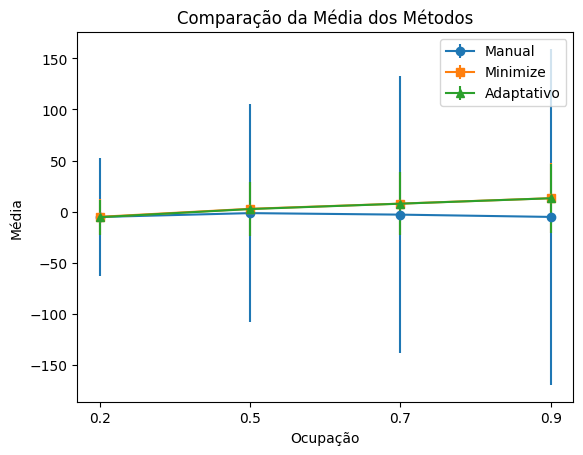

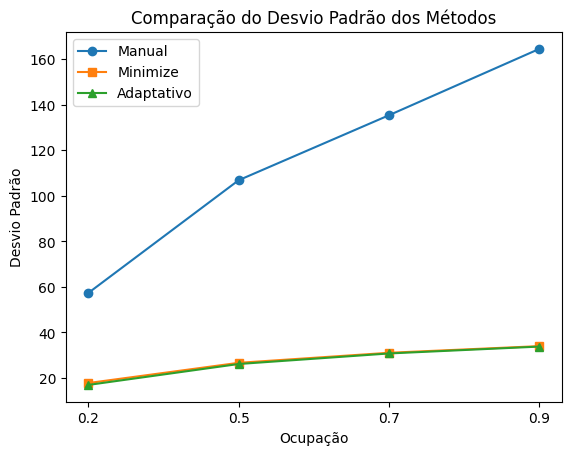

In [ ]:
#Media
mean_manual = [np.mean(res_manual[i]['Error']) for i in range(len(res_manual))]
mean_minimize = [np.mean(res_minimize[i]['Error']) for i in range(len(res_minimize))]
mean_adaptativo = [np.mean(res_adaptativo[i]['Error']) for i in range(len(res_adaptativo))]

#Desvio padrão
std_manual = [np.std(res_manual[i]['Error']) for i in range(len(res_manual))]
std_minimize = [np.std(res_minimize[i]['Error']) for i in range(len(res_minimize))]
std_adaptativo = [np.std(res_adaptativo[i]['Error']) for i in range(len(res_adaptativo))]

for i in range(len(res_manual)):
    print(f"Ocupação: {occ_name[i]}")
    print(f"Média Manual: {mean_manual[i]:.2f}, Média Minimize: {mean_minimize[i]:.2f}, Média Adaptativo: {mean_adaptativo[i]:.2f}")
    print(f"Desvio Padrão Manual: {std_manual[i]:.2f}, Desvio Padrão Minimize: {std_minimize[i]:.2f}, Desvio Padrão Adaptativo: {std_adaptativo[i]:.2f}")
    print("\n")

#Grafico Media
plt.errorbar(occ_name, mean_manual, yerr=std_manual, marker='o', label='Manual')
plt.errorbar(occ_name, mean_minimize, yerr=std_minimize, marker='s', label='Minimize')
plt.errorbar(occ_name, mean_adaptativo, yerr=std_adaptativo, marker='^', label='Adaptativo')
plt.xlabel('Ocupação')
plt.ylabel('Média')
plt.title('Comparação da Média dos Métodos')
plt.legend()
plt.show()

#Grafico Desvio padrão
plt.plot(occ_name, std_manual, marker='o', label='Manual')
plt.plot(occ_name, std_minimize, marker='s', label='Minimize')
plt.plot(occ_name, std_adaptativo, marker='^', label='Adaptativo')
plt.xlabel('Ocupação')
plt.ylabel('Desvio Padrão')
plt.title('Comparação do Desvio Padrão dos Métodos')
plt.legend()
plt.show()